In [2]:
import numpy as np 
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

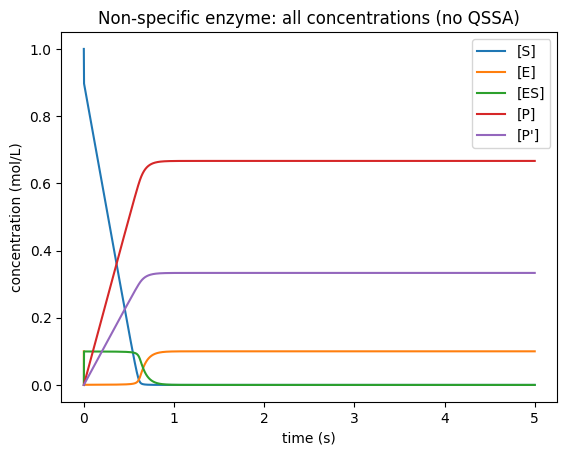

In [9]:
kf =1e4
kb=20.0
kcat1=10
kcat2=5.0

S0=1.0
E0=0.1
ES0=0.0
P0=0.0
Pp0=0.0

def equations(variables,t):
    S,E,ES,P,Pp=variables
    dS=-kf*S*E+kb*ES
    dE=-kf*E*S+kb*ES+kcat1*ES+kcat2*ES
    dES=-kcat2*ES-kcat1*ES+kf*E*S-kb*ES
    dP=kcat1*ES
    dPp=kcat2*ES


    return dS,dE,dES,dP,dPp

initial_conditions =[S0,E0,ES0,P0,Pp0]
t=np.linspace(start=0,stop=5,num=2001)

results=odeint(equations,initial_conditions,t)
S,E,ES,P,Pp=results.T

plt.figure()
plt.plot(t, S,  label='[S]')
plt.plot(t, E,  label='[E]')
plt.plot(t, ES, label='[ES]')
plt.plot(t, P,  label='[P]')
plt.plot(t, Pp, label="[P']")
plt.xlabel('time (s)')
plt.ylabel('concentration (mol/L)')
plt.title('Non-specific enzyme: all concentrations (no QSSA)')
plt.legend()
plt.show()